In [1]:
import pandas as pd

In [33]:
import pandas as pd

dsc_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-17/20260717-DSC-UAFW.xls')
dsc_og_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-17/20260717-DSC-UAFW.xls', 
                          sheet_name="Ramp 10.00 °Cmin to 30.00 °C",
                          header =1
                          )
print(dsc_xl.sheet_names)
dsc_og_df
# dsc_og_df = dsc_og_df.rename(columns={'GUID': "col", "b2f4ff98-5721-4145-bc5f-4becc4a889ae": "values"})
# print(dsc_og_df.iloc[2005,1], dsc_og_df.iloc[2006,1])
# # print(len(dsc_og_df["col"]))
# print(dsc_og_df)

['Details', 'Ramp 10.00 °Cmin to 30.00 °C']


,Temperature,Heat Capacity (Normalized),Heat Flow (Normalized)
0,°C,J/(g.°C),W/g
1,-79.82,0,0.045216
2,-79.82,0,0.04524
3,-79.82,0,0.045175
4,-79.82,0,0.045119
...,...,...,...
6587,28.34,NaN,NaN
6588,28.35,NaN,NaN
6589,28.37,NaN,NaN
6590,28.39,NaN,NaN


In [14]:
import pandas as pd
import numpy as np

temp = dsc_og_df["values"][::2].values.tolist()
Cp = dsc_og_df["values"][1::2].values.tolist()

dsc_df = pd.DataFrame({
    "Temperature": pd.Series(temp),
    "Heat Flow": pd.Series(Cp)
})

dsc_df

,Temperature,Heat Flow
0,-77.96781,1.033888
1,-77.01757,1.03613
2,-76.06734,1.038151
3,-75.1171,1.039945
4,-74.16685,1.041512
...,...,...
999,0.999445,390.5582
1000,0.999404,391.4868
1001,0.999309,392.4153
1002,0.999164,393.3438


In [23]:
for idx, row in dsc_df.iterrows():
    if row.isna().any():
        print(idx, row)

500 Temperature                   NaT
Heat Flow     2026-07-01 17:28:20
Name: 500, dtype: datetime64[us]
1003 Temperature    0.998938
Heat Flow           NaN
Name: 1003, dtype: object


ValueError: could not convert string to float: 'From -69.998  to 394.272  at 2.000/min'

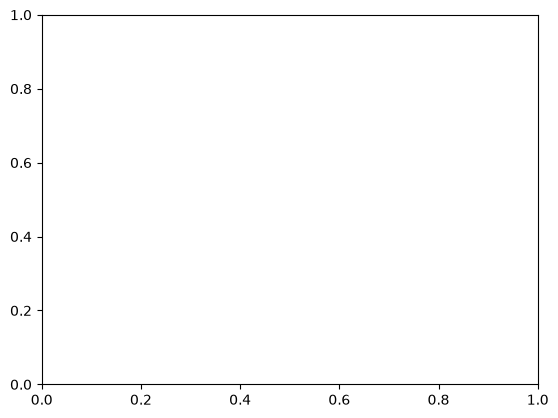

In [16]:
import matplotlib.pyplot as plt

plt.plot(dsc_df["Temperature"], dsc_df["Heat Flow"])